# **Exploratory Data Analysis**

In [1]:
# importazione librerie
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# visualizzazione output
pd.set_option('display.max_columns', None)

# dati puliti
distribution_center_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\distribution_center_clean.csv")
events_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\events_clean.csv")
inventory_items_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\inventory_items_clean.csv")
order_items_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\order_items_clean.csv")
orders_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\orders_clean.csv")
products_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\products_clean.csv")
users_clean=pd.read_csv("C:\\Users\\Dell\\Documents\\Progetti\\aggiornamento_prog_finale\\f)_data\\clean_data\\users_clean.csv")

### Website Activity (events)

In [3]:
# Creiamo una colonna temporanea per distinguere i due gruppi
events_clean['user_type'] = events_clean['user_id'].apply(
    lambda x: 'Anonimo (Unknown)' if x == 'Unknown' else 'Registrato'
)

# Calcolo della percentuale
totale_sessioni = len(events_clean)
n_anonimi = (events_clean['user_type'] == 'Anonimo (Unknown)').sum()
pct_anonimi = (n_anonimi / totale_sessioni) * 100

print(f"--- ANALISI COPERTURA UTENTI ---")
print(f"Su un totale di {totale_sessioni:,} sessioni:")
print(f"• Utenti Anonimi: {pct_anonimi:.1f}%")
print(f"• Utenti Registrati: {100 - pct_anonimi:.1f}%")
print("-" * 30)

# Confronto del comportamento
confronto_comportamento = pd.crosstab(
    events_clean['user_type'], 
    events_clean['event_type'], 
    normalize='index'
) * 100

print("\n--- DOVE SI TROVANO GLI UTENTI NELL'ULTIMO STEP? (Valori in %) ---")
print(confronto_comportamento.round(1))

--- ANALISI COPERTURA UTENTI ---
Su un totale di 688,939 sessioni:
• Utenti Anonimi: 73.4%
• Utenti Registrati: 26.6%
------------------------------

--- DOVE SI TROVANO GLI UTENTI NELL'ULTIMO STEP? (Valori in %) ---
event_type         cancel  cart  product  purchase
user_type                                         
Anonimo (Unknown)    25.1  25.0     49.9       0.0
Registrato            0.0   0.0      0.0     100.0


In [4]:
"""
Va tenuto conto che events registra solo l'ultimo evento per sessione.
Perché un utente anonimo dovrebbe avere "cancel" come ultima azione della sessione nel 25% dei casi?
Ipotesi: Potrebbe essere che il sistema forzi la registrazione per procedere dal carrello al pagamento. 
L'utente arriva al carrello, vede il muro del "Registrati/Accedi", e clicca su annulla o chiude la sessione.
Questi utenti però mostrano un chiaro interesse all'acquisto.
Interventi di marketing (es. Guest Checkout o Social Login) potrebbero aiutare.
"""

'\nVa tenuto conto che events registra solo l\'ultimo evento per sessione.\nPerché un utente anonimo dovrebbe avere "cancel" come ultima azione della sessione nel 25% dei casi?\nIpotesi: Potrebbe essere che il sistema forzi la registrazione per procedere dal carrello al pagamento. \nL\'utente arriva al carrello, vede il muro del "Registrati/Accedi", e clicca su annulla o chiude la sessione.\nQuesti utenti però mostrano un chiaro interesse all\'acquisto.\nInterventi di marketing (es. Guest Checkout o Social Login) potrebbero aiutare.\n'

In [4]:
# Contiamo quante sessioni finiscono con 'purchase': Conversion Rate
sessioni_totali = len(events_clean)
acquisti = len(events_clean[events_clean['event_type'] == 'purchase'])

conversion_rate = (acquisti / sessioni_totali) * 100

print(f"--- ANALISI CONVERSIONE ---")
print(f"Sessioni analizzate: {sessioni_totali:,}")
print(f"Acquisti completati: {acquisti:,}")
print(f"Conversion Rate Totale: {conversion_rate:.2f}%")

--- ANALISI CONVERSIONE ---
Sessioni analizzate: 688,939
Acquisti completati: 183,181
Conversion Rate Totale: 26.59%


In [5]:
# Calcoliamo il CR per ogni sorgente di traffico
conversion_by_traffic_source = events_clean.groupby('traffic_source')['event_type'].apply(lambda x: (x == 'purchase').mean()*100)
conversion_by_traffic_source=conversion_by_traffic_source.sort_values(ascending=False)
conversion_by_traffic_source

print("\n--- CONVERSION RATE PER SORGENTE ---")
print(conversion_by_traffic_source.map('{:.2f}%'.format))


--- CONVERSION RATE PER SORGENTE ---
traffic_source
YouTube     26.85%
Email       26.62%
Organic     26.61%
Facebook    26.59%
Adwords     26.45%
Name: event_type, dtype: object


In [7]:
""" 
Organic indica gli utenti che arrivano sul sito senza che ci sia stata una campagna di marketing pagata o un'azione specifica.
Adwords  si riferisce al traffico proveniente dalle campagne pubblicitarie a pagamento di Google
"""

" \nOrganic indica gli utenti che arrivano sul sito senza che ci sia stata una campagna di marketing pagata o un'azione specifica.\nAdwords  si riferisce al traffico proveniente dalle campagne pubblicitarie a pagamento di Google\n"

In [8]:
"""Tutti i canali di acquisizione sembrano portare utenti con la stessa identica propensione all'acquisto."""

"Tutti i canali di acquisizione sembrano portare utenti con la stessa identica propensione all'acquisto."

In [6]:
# Creiamo un dizionario di normalizzazione
country_mapping = {
    'España': 'Spain',
}

# Applichiamo la correzione
# .replace() cerca i valori esatti definiti nel dizionario
events_clean['country'] = events_clean['country'].replace(country_mapping)

print(events_clean['country'].unique())

['Brasil' 'Japan' 'South Korea' 'Belgium' 'France' 'China' 'United States'
 'Germany' 'Spain' 'Australia' 'Poland' 'Colombia' 'United Kingdom'
 'Unknown' 'Austria']


In [7]:
# Calcoliamo il CR per ogni paese
conversion_by_country = events_clean.groupby('country')['event_type'].apply(lambda x: (x == 'purchase').mean()*100)
conversion_by_country=conversion_by_country.sort_values(ascending=False)
conversion_by_country

print("--- CONVERSION RATE PER PAESE ---")
print(conversion_by_country.map('{:.2f}%'.format))

--- CONVERSION RATE PER PAESE ---
country
Austria           61.54%
Japan             27.88%
Belgium           27.16%
Germany           26.77%
China             26.63%
United States     26.63%
Spain             26.62%
United Kingdom    26.59%
France            26.52%
Poland            26.51%
Brasil            26.39%
South Korea       26.26%
Australia         25.91%
Colombia          25.47%
Unknown            0.00%
Name: event_type, dtype: object


In [8]:
# check di volume
volumi_paese = events_clean['country'].value_counts()
print("\n--- VOLUME SESSIONI PER PAESE ---")
print(volumi_paese)


--- VOLUME SESSIONI PER PAESE ---
country
China             231328
United States     153994
Brasil             99675
South Korea        35705
France             31964
United Kingdom     31323
Spain              30980
Germany            28174
Japan              16665
Australia          14905
Belgium             8514
Colombia            4004
Poland              1641
Unknown               41
Austria               26
Name: count, dtype: int64


In [12]:
"""
Il "Caso Austria": Conversion Rate del 61.54%, ma ci sono solo 26 sessioni.
È un outlier dovuto al campione ridotto.
"""

'\nIl "Caso Austria": Conversion Rate del 61.54%, ma ci sono solo 26 sessioni.\nÈ un outlier dovuto al campione ridotto.\n'

In [9]:
# Osserviamo come varia, a livello globale, il CR nel corso degli anni
conversion_by_year = events_clean.groupby('year',as_index=False)['event_type'].apply(lambda x: (x == 'purchase').mean()*100)
conversion_by_year=conversion_by_year.sort_values(by='year', ascending=True)
print("\n--- CONVERSIONE PER ANNO ---")
print(conversion_by_year)


--- CONVERSIONE PER ANNO ---
   year  event_type
0  2019    2.521496
1  2020    7.681548
2  2021   12.924494
3  2022   19.078819
4  2023   26.190451
5  2024   34.449157
6  2025   46.834816
7  2026   67.783425


In [14]:
"""
Impennata notevole. Ricordiamo che stiamo lavorando con dati fittizi.
Essendo cambiato così tanto negli anni, 
in Power BI sarà interessante vedere come varia il CR dei paesi in base al range di anni selezionato
"""

'\nImpennata notevole. Ricordiamo che stiamo lavorando con dati fittizi.\nEssendo cambiato così tanto negli anni, \nin Power BI sarà interessante vedere come varia il CR dei paesi in base al range di anni selezionato\n'

### Panoramica Users

In [10]:
gender_dist = users_clean['gender'].value_counts(normalize=True) * 100
print("--- DISTRIBUZIONE PER GENERE ---")
print(gender_dist.map('{:.2f}%'.format))

--- DISTRIBUZIONE PER GENERE ---
gender
M    50.17%
F    49.83%
Name: proportion, dtype: object


In [16]:
"""Questa distribuzione ci suggerisce un catalogo generalista"""

'Questa distribuzione ci suggerisce un catalogo generalista'

In [11]:
age_dist = users_clean['age_group'].value_counts(normalize=True) * 100
print("\n--- DISTRIBUZIONE PER FASCIA D'ETÀ ---")
print(age_dist.map('{:.2f}%'.format))


--- DISTRIBUZIONE PER FASCIA D'ETÀ ---
age_group
Middle-aged Adult    33.90%
Adult                33.83%
Young                22.09%
Senior               10.18%
Name: proportion, dtype: object


In [18]:
"""
Il cuore pulsante del sito è la fascia Adult e Middle-aged Adult. Insieme coprono quasi il 68% dell'utenza.
Questa potrebbe essere una buona notizia. Solitamente le fasce tra i 26 e i 60 anni sono quelle con la maggiore disponibilità economica e stabilità.
I giovani sono una fetta importante ma non primaria, mentre i Senior sembrano essere il gruppo meno intercettato. 
Potrebbe essere un'opportunità di espansione o semplicemente il riflesso di un e-commerce con brand molto moderni.
"""

"\nIl cuore pulsante del sito è la fascia Adult e Middle-aged Adult. Insieme coprono quasi il 68% dell'utenza.\nQuesta potrebbe essere una buona notizia. Solitamente le fasce tra i 26 e i 60 anni sono quelle con la maggiore disponibilità economica e stabilità.\nI giovani sono una fetta importante ma non primaria, mentre i Senior sembrano essere il gruppo meno intercettato. \nPotrebbe essere un'opportunità di espansione o semplicemente il riflesso di un e-commerce con brand molto moderni.\n"

In [12]:
age_gender_cross = pd.crosstab(users_clean['age_group'], 
                               users_clean['gender'], 
                               normalize='index') * 100

print("--- PERCENTUALE GENERE PER FASCIA D'ETÀ ---")
print(age_gender_cross.round(2))

# Calcoliamo l'età media per genere per vedere se ci sono scostamenti
mean_age_gender = users_clean.groupby('gender')['age'].mean()
print("\n--- ETÀ MEDIA PER GENERE ---")
print(mean_age_gender.round(1))

--- PERCENTUALE GENERE PER FASCIA D'ETÀ ---
gender                 F      M
age_group                      
Adult              49.55  50.45
Middle-aged Adult  50.01  49.99
Senior             50.01  49.99
Young              49.91  50.09

--- ETÀ MEDIA PER GENERE ---
gender
F    41.0
M    41.0
Name: age, dtype: float64


In [20]:
"""
In tutte le fasce, lo scostamento tra M e F è inferiore all'1%
Il fatto che sia gli uomini che le donne abbiano un'età media di 41.0 anni è un dato molto forte. 
Ci dice che l'e-commerce attrae persone nella stessa fase della vita, indipendentemente dal sesso.
"""

"\nIn tutte le fasce, lo scostamento tra M e F è inferiore all'1%\nIl fatto che sia gli uomini che le donne abbiano un'età media di 41.0 anni è un dato molto forte. \nCi dice che l'e-commerce attrae persone nella stessa fase della vita, indipendentemente dal sesso.\n"

In [13]:
# Creiamo una maschera per identificare gli ordini "validi" (escludiamo cancellati e resi)
valid_items = order_items_clean[~order_items_clean['status'].isin(['Cancelled', 'Returned'])]
# Uniamo le tabelle Users e Order Items
df_user_spending = pd.merge(
    valid_items[['user_id', 'sale_price']], 
    users_clean[['id', 'gender', 'age_group', 'country']], 
    left_on='user_id', 
    right_on='id'
)

# Calcoliamo la spesa media per Gruppo
spending_analysis = df_user_spending.groupby(['age_group', 'gender'])['sale_price'].mean().unstack()

# Calcoliamo anche la spesa totale
total_revenue_analysis = df_user_spending.groupby(['age_group', 'gender'])['sale_price'].sum().unstack()

print("--- SPESA MEDIA PER SEGMENTO ---")
print(spending_analysis.round(2))

print("\n--- RICAVO TOTALE PER SEGMENTO ---")
print(total_revenue_analysis.round(2))

--- SPESA MEDIA PER SEGMENTO ---
gender                 F      M
age_group                      
Adult              55.12  64.45
Middle-aged Adult  55.63  62.88
Senior             55.24  63.91
Young              55.56  62.97

--- RICAVO TOTALE PER SEGMENTO ---
gender                      F           M
age_group                                
Adult              1255242.60  1524678.93
Middle-aged Adult  1280563.50  1436418.55
Senior              383785.17   439013.62
Young               833963.15   937221.05


In [22]:
"""
Nonostante siano numericamente uguali, gli uomini spendono sensibilmente di più delle donne.
I Maschi tra i 26-45 anni sono il miglior cliente sia per spesa media che per contributo totale al fatturato.
"""

'\nNonostante siano numericamente uguali, gli uomini spendono sensibilmente di più delle donne.\nI Maschi tra i 26-45 anni sono il miglior cliente sia per spesa media che per contributo totale al fatturato.\n'

In [14]:
# Analizziamo le categorie merceologiche per vedere se il vantaggio maschile deriva dal prezzo dei singoli articoli o da una diversa tipologia di shopping
# Uniamo i prodotti agli ordini e poi agli utenti
df_items_prod = pd.merge(valid_items, products_clean[['id', 'category']], left_on='product_id', right_on='id')
df_full = pd.merge(df_items_prod, users_clean[['id', 'gender']], left_on='user_id', right_on='id')

# Top 5 Categorie per spesa totale (Uomini vs Donne)
top_cat_gender = df_full.groupby(['gender', 'category'])['sale_price'].sum().reset_index()

top_5_f = top_cat_gender[top_cat_gender['gender'] == 'F'].sort_values(by='sale_price', ascending=False).head(5)
top_5_m = top_cat_gender[top_cat_gender['gender'] == 'M'].sort_values(by='sale_price', ascending=False).head(5)

print("--- TOP 5 CATEGORIE PER RICAVO (FEMMINE) ---")
print(top_5_f[['category', 'sale_price']])

print("\n--- TOP 5 CATEGORIE PER RICAVO (MASCHI) ---")
print(top_5_m[['category', 'sale_price']])

--- TOP 5 CATEGORIE PER RICAVO (FEMMINE) ---
             category  sale_price
7               Jeans   346383.82
11  Outerwear & Coats   345624.17
6           Intimates   337336.83
4             Dresses   325727.47
20               Swim   244021.77

--- TOP 5 CATEGORIE PER RICAVO (MASCHI) ---
               category  sale_price
26    Outerwear & Coats   653779.67
25                Jeans   578348.82
31  Suits & Sport Coats   500458.87
32             Sweaters   421957.38
27                Pants   320085.86


In [24]:
"""
Gli uomini spendono quasi il doppio delle donne in cappotti e giacche. 
Poiché l'outerwear è solitamente la categoria con il prezzo unitario più alto, questo spiega da solo gran parte del divario di spesa media.
il target maschile tende verso un abbigliamento più costoso e strutturato (giacche, completi), 
mentre le donne si concentrano anche su categorie a prezzo più basso come Intimates e Dresses.
"""

"\nGli uomini spendono quasi il doppio delle donne in cappotti e giacche. \nPoiché l'outerwear è solitamente la categoria con il prezzo unitario più alto, questo spiega da solo gran parte del divario di spesa media.\nil target maschile tende verso un abbigliamento più costoso e strutturato (giacche, completi), \nmentre le donne si concentrano anche su categorie a prezzo più basso come Intimates e Dresses.\n"

### Analisi geografica

In [15]:
country_dist = users_clean['country'].value_counts()
country_dist_pct = users_clean['country'].value_counts(normalize=True) * 100
# Top 10 Città nel mondo per numero di iscritti
top_cities = users_clean['city'].value_counts().head(10)

print("--- DISTRIBUZIONE UTENTI PER PAESE ---")
df_geo = pd.DataFrame({'Conteggio': country_dist, 'Percentuale': country_dist_pct})
print(df_geo.head(10).round(2))

print("\n--- TOP 10 CITTÀ PER NUMERO DI UTENTI ---")
print(top_cities)

--- DISTRIBUZIONE UTENTI PER PAESE ---
                Conteggio  Percentuale
country                               
China               34018        34.02
United States       22644        22.64
Brasil              14546        14.55
South Korea          5314         5.31
France               4677         4.68
United Kingdom       4554         4.55
Germany              4101         4.10
Spain                3966         3.97
Japan                2468         2.47
Australia            2197         2.20

--- TOP 10 CITTÀ PER NUMERO DI UTENTI ---
city
Shanghai    2416
Beijing     2019
Seoul       1448
Shenzhen    1344
Unknown      990
Dongguan     900
Chengdu      846
Tokyo        846
New York     806
Wuhan        791
Name: count, dtype: int64


In [26]:
"""
L'analisi geografica ci mostra il predominio assoluto della Cina, che da sola copre il 34% degli utenti, seguita da Stati Uniti (22.6%) e Brasile (14.5%). 
La concentrazione urbana è impressionante: Shanghai e Beijing sono i principali hub commerciali, 
con una forte presenza asiatica che include anche Seoul e Tokyo. 
Questo dato suggerisce che il cuore del business batte nelle grandi metropoli del Far East e del Nord America.
"""

"\nL'analisi geografica ci mostra il predominio assoluto della Cina, che da sola copre il 34% degli utenti, seguita da Stati Uniti (22.6%) e Brasile (14.5%). \nLa concentrazione urbana è impressionante: Shanghai e Beijing sono i principali hub commerciali, \ncon una forte presenza asiatica che include anche Seoul e Tokyo. \nQuesto dato suggerisce che il cuore del business batte nelle grandi metropoli del Far East e del Nord America.\n"

In [16]:
# Chi spende di più?
geo_spending = df_user_spending.groupby('country')['sale_price'].agg(['mean', 'sum', 'count']).sort_values(by='sum', ascending=False)

# 2. Rinominiamo le colonne per chiarezza
geo_spending.columns = ['Spesa Media', 'Ricavo Totale', 'Numero Ordini']

print("--- ANALISI ECONOMICA PER PAESE ---")
print(geo_spending.head(10).round(2))

--- ANALISI ECONOMICA PER PAESE ---
                Spesa Media  Ricavo Totale  Numero Ordini
country                                                  
China                 59.50     2748064.09          46184
United States         59.67     1844898.11          30916
Brasil                59.73     1175286.40          19677
South Korea           59.23      421025.60           7108
France                59.15      377820.12           6387
United Kingdom        59.18      370889.43           6267
Germany               58.67      333054.40           5677
Spain                 58.27      313567.93           5381
Japan                 61.91      215928.68           3488
Australia             58.86      164927.11           2802


In [28]:
"""
L'analisi economica conferma che la Cina è il motore del business con oltre 2,7 milioni di ricavi, 
distaccando nettamente USA e Brasile. Tuttavia, il dato più interessante è la spesa media: 
mentre la maggior parte dei paesi si attesta sui 59$, il Giappone svetta con 61,91$, 
rivelandosi il mercato con i clienti "più alto-spendenti" per singolo ordine.
"""

'\nL\'analisi economica conferma che la Cina è il motore del business con oltre 2,7 milioni di ricavi, \ndistaccando nettamente USA e Brasile. Tuttavia, il dato più interessante è la spesa media: \nmentre la maggior parte dei paesi si attesta sui 59$, il Giappone svetta con 61,91$, \nrivelandosi il mercato con i clienti "più alto-spendenti" per singolo ordine.\n'

In [17]:
order_items_clean['is_returned'] = order_items_clean['status'] == 'Returned'
# Uniamo con i dati geografici e le categorie di prodotto
df_returns = pd.merge(order_items_clean, users_clean[['id', 'country']], left_on='user_id', right_on='id')
df_returns = pd.merge(df_returns, products_clean[['id', 'category']], left_on='product_id', right_on='id')

# Calcolo Return Rate per PAESE
rr_country = df_returns.groupby('country')['is_returned'].mean() * 100
rr_country = rr_country.sort_values(ascending=False).head(10)

# Calcolo Return Rate per CATEGORIA
rr_category = df_returns.groupby('category')['is_returned'].mean() * 100
rr_category = rr_category.sort_values(ascending=False).head(10)

print("--- PERCENTUALE RESI PER PAESE (Top 10) ---")
print(rr_country.map('{:.2f}%'.format))

print("\n--- PERCENTUALE RESI PER CATEGORIA (Top 10) ---")
print(rr_category.map('{:.2f}%'.format))

--- PERCENTUALE RESI PER PAESE (Top 10) ---
country
Colombia          20.93%
Germany           10.69%
Australia         10.64%
Belgium           10.03%
Brasil             9.98%
China              9.97%
United Kingdom     9.94%
United States      9.87%
France             9.81%
Spain              9.68%
Name: is_returned, dtype: object

--- PERCENTUALE RESI PER CATEGORIA (Top 10) ---
category
Leggings               11.25%
Jumpsuits & Rompers    10.56%
Shorts                 10.44%
Pants & Capris         10.37%
Tops & Tees            10.35%
Socks & Hosiery        10.20%
Swim                   10.10%
Sleep & Lounge         10.09%
Jeans                  10.02%
Outerwear & Coats      10.00%
Name: is_returned, dtype: object


In [30]:
"""
L'analisi dei resi rivela un'anomalia critica in Colombia, segnalando possibili problemi logistici o doganali locali.
da sottolineare come la Colombia sia poco rappresentata nel dataset, 
un tasso di reso così alto su un volume molto piccolo potrebbe essere causato in realtà da pochiordini andati male 
A livello merceologico non sembrano esserci particolari anomalie
"""

"\nL'analisi dei resi rivela un'anomalia critica in Colombia, segnalando possibili problemi logistici o doganali locali.\nda sottolineare come la Colombia sia poco rappresentata nel dataset, \nun tasso di reso così alto su un volume molto piccolo potrebbe essere causato in realtà da pochiordini andati male \nA livello merceologico non sembrano esserci particolari anomalie\n"

### Stagionalità

--- PATTERN STAGIONALE AGGREGATO (STORICO) ---
    month  volume_vendite  revenue_totale    AOV  revenue_weight_pct
0       1           14484       852970.44  58.89               10.54
1       2           18332      1082038.56  59.02               13.37
2       3            8384       496241.92  59.19                6.13
3       4            8421       510035.98  60.57                6.30
4       5            9219       549672.04  59.62                6.79
5       6            9316       559158.61  60.02                6.91
6       7            9845       588246.64  59.75                7.27
7       8           10404       616639.50  59.27                7.62
8       9           10785       637194.22  59.08                7.88
9      10           11449       675051.07  58.96                8.34
10     11           12137       739232.19  60.91                9.14
11     12           13229       784405.40  59.29                9.69


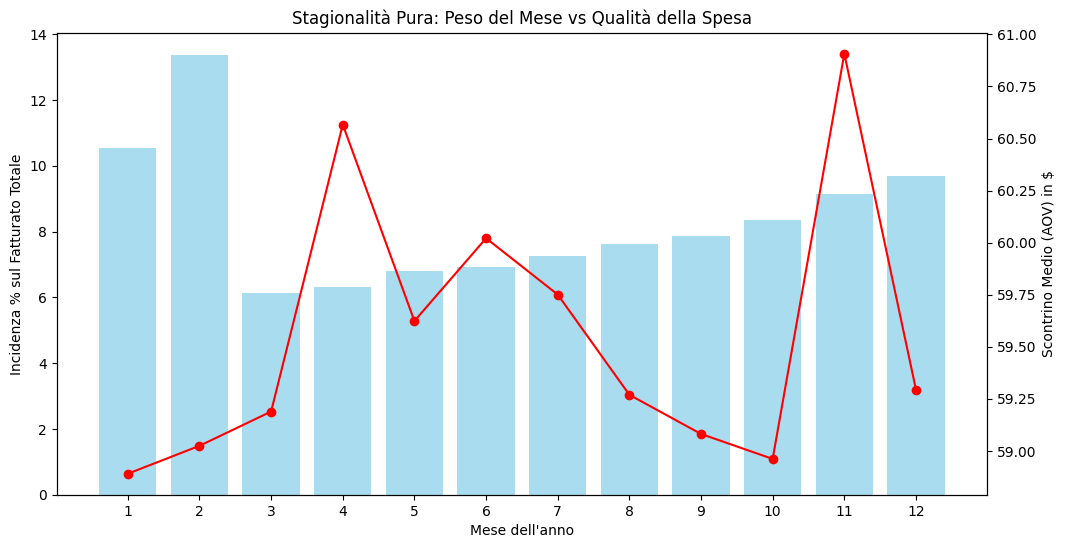

In [18]:
# Merge tra Orders e valid_items per associare le date ai ricavi
df_seasonal_complete = pd.merge(
    valid_items[['order_id', 'sale_price']], 
    orders_clean[['order_id', 'month', 'year']], 
    on='order_id'
)

# Aggregazione per Mese: Calcoliamo Volume e Revenue Totale storica
seasonal_pattern = df_seasonal_complete.groupby('month').agg(
    volume_vendite=('order_id', 'count'),
    revenue_totale=('sale_price', 'sum')
).reset_index()

# Calcolo metriche di confronto
total_historic_revenue = seasonal_pattern['revenue_totale'].sum()
seasonal_pattern['AOV'] = seasonal_pattern['revenue_totale'] / seasonal_pattern['volume_vendite']
seasonal_pattern['revenue_weight_pct'] = (seasonal_pattern['revenue_totale'] / total_historic_revenue) * 100

print("--- PATTERN STAGIONALE AGGREGATO (STORICO) ---")
print(seasonal_pattern.round(2))

# Visualizzazione
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
ax1.bar(seasonal_pattern['month'], seasonal_pattern['revenue_weight_pct'], color='skyblue', alpha=0.7)
ax2.plot(seasonal_pattern['month'], seasonal_pattern['AOV'], color='red', marker='o', label='Spesa Media (AOV)')

ax1.set_xlabel('Mese dell\'anno')
ax1.set_ylabel('Incidenza % sul Fatturato Totale')
ax2.set_ylabel('Scontrino Medio (AOV) in $')
plt.title('Stagionalità Pura: Peso del Mese vs Qualità della Spesa')
plt.xticks(range(1, 13))
plt.show()

In [ ]:
"""
L'analisi rivela una stagionalità marcata, 
una grande percentuale del fatturato si concentra nel periodo invernale (da Novembre a febbraio).
Ce lo potevamo aspettare in quanto la categoria che porta più fatturato è: Outerwear & Coats
"""

### Logistica

In [19]:
df_logistica = pd.merge(
    inventory_items_clean, 
    distribution_center_clean, 
    left_on='product_distribution_center_id', 
    right_on='id'
)

# Aggregazione: Volume totale, Merce a terra (in_stock=1) e permanenza media
report_centri = df_logistica.groupby('name').agg(
    totale_articoli=('id_x', 'count'),
    disponibili=('in_stock', 'sum'),
    giorni_medi_stock=('days_in_stock', 'mean')
).reset_index()

# Calcolo % di stock disponibile
report_centri['percentuale_disponibile'] = (report_centri['disponibili'] / report_centri['totale_articoli']) * 100
report_centri = report_centri.sort_values(by='totale_articoli', ascending=False)

print("--- REPORT LOGISTICO PER CENTRO ---")
print(report_centri.round(2))

--- REPORT LOGISTICO PER CENTRO ---
                                          name  totale_articoli  disponibili  \
4                                   Memphis TN            65993        41587   
1                                   Chicago IL            64671        40673   
2                                   Houston TX            61349        38642   
5                                    Mobile AL            49164        30880   
3                               Los Angeles CA            46764        29520   
7                              Philadelphia PA            45138        28380   
0                                Charleston SC            44759        28180   
8  Port Authority of New York/New Jersey NY/NJ            44101        27777   
6                               New Orleans LA            35240        22235   
9                                  Savannah GA            31987        20173   

   giorni_medi_stock  percentuale_disponibile  
4             721.40               

In [ ]:
"""
la merce resta a scaffale, in media, per circa due anni.
Abbiamo un enorme problema di obsolescenza o di prodotti che non incontrano la domanda del mercato.
Tutti i 10 centri di distribuzione sono situati negli Stati Uniti.
Come iplica ciò i tempi di spedizione?"""

In [ ]:
df_shipping_geo = pd.merge(
    orders_clean[['order_id', 'user_id', 'days_for_shipping', 'days_for_delivery']], 
    users_clean[['id', 'country']], 
    left_on='user_id', 
    right_on='id')

# Filtriamo solo gli ordini completati e con dati di shipping/delivery validi
df_valid_logistics = df_shipping_geo[
    (df_shipping_geo['days_for_shipping'] > 0) & 
    (df_shipping_geo['days_for_delivery'] > 0)
]


refined_shipping = df_valid_logistics.groupby('country').agg(
    media_spedizione=('days_for_shipping', 'mean'),
    media_consegna=('days_for_delivery', 'mean'),
    volume_reale=('order_id', 'count')
).reset_index()

print("--- TEMPI LOGISTICI REALI (SOLO ORDINI COMPLETATI) ---")
print(refined_shipping.round(2).sort_values('media_consegna', ascending=False))

--- TEMPI LOGISTICI REALI (SOLO ORDINI COMPLETATI) ---
           country  media_spedizione  media_consegna  volume_reale
0        Australia              1.47            2.53           514
9      South Korea              1.50            2.52          1189
10           Spain              1.49            2.52           939
6          Germany              1.49            2.51          1008
8           Poland              1.42            2.50            52
12   United States              1.51            2.50          5163
3            China              1.50            2.49          7822
2           Brasil              1.50            2.49          3480
1          Belgium              1.48            2.49           306
7            Japan              1.50            2.47           596
5           France              1.49            2.46          1102
11  United Kingdom              1.48            2.46          1123
4         Colombia              1.20            2.20             5


In [ ]:
"""
Il risultato ottenuto è molto strano: tutti i paesi registrano tempi di consegna quasi identici, circa 2.5 giorni. 
Si tratta di un'efficienza fisicamente impossibile per spedizioni transoceaniche che partono esclusivamente dai 10 centri situati negli Stati Uniti. 
Questa omogeneità suggerisce che il dato sia frutto di una simulazione ottimistica che non tiene conto dei reali tempi. 
Resta emblematico il caso della Colombia, la più veloce con 2.20 giorni, il che conferma che il suo elevato tasso di resi (20.93%) non è imputabile a ritardi logistici.
"""

In [ ]:
# Ci sono dei prodotti senza scorte?
# Contiamo le unità disponibili (in_stock = 1) per ogni prodotto nell'inventario
available_stock = inventory_items_clean[inventory_items_clean['in_stock'] == 1].groupby('product_id').size().reset_index(name='unita_disponibili')

# Uniamo con la tabella Products
df_stock_check = pd.merge(
    products_clean[['id', 'name', 'category']], 
    available_stock, 
    left_on='id', 
    right_on='product_id', 
    how='left'
).fillna(0) # Se non c'è nel merge, le unità sono 0


out_of_stock = df_stock_check[df_stock_check['unita_disponibili'] == 0]

print(f"--- ANALISI STOCKOUT ---")
print(f"Prodotti totali in catalogo: {len(products_clean)}")
print(f"Prodotti attualmente a zero scorte: {len(out_of_stock)}")
print("\nPrime categorie per mancanza di stock:")
print(out_of_stock['category'].value_counts().head(5))

--- ANALISI STOCKOUT ---
Prodotti totali in catalogo: 29120
Prodotti attualmente a zero scorte: 74

Prime categorie per mancanza di stock:
category
Plus                             8
Intimates                        7
Tops & Tees                      7
Active                           6
Fashion Hoodies & Sweatshirts    5
Name: count, dtype: int64


In [ ]:
"""
Con soli 74 prodotti a zero scorte su oltre 29.000, il problema non è la mancanza di merce, ma l'invenduto. 
Questo dato valida l'allarme sui 720 giorni di giacenza media,
confermando che i magazzini sono saturi di prodotti "dormienti" che non ruotano.
"""